In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, precision_score

In [2]:
df = pd.read_csv("Data/student_exam_performance_dataset (1).csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  10000 non-null  object 
 1   gender                      10000 non-null  object 
 2   age                         10000 non-null  int64  
 3   parental_education          10000 non-null  object 
 4   family_income               10000 non-null  object 
 5   internet_access             10000 non-null  object 
 6   study_environment           10000 non-null  object 
 7   study_hours_per_day         10000 non-null  float64
 8   attendance_rate             10000 non-null  float64
 9   sleep_hours                 10000 non-null  float64
 10  social_media_hours          10000 non-null  float64
 11  assignment_completion_rate  10000 non-null  float64
 12  participation_score         10000 non-null  float64
 13  online_courses_completed    1000

In [4]:
df.head()

,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,...,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,Fail,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,...,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,Pass,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,...,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,Fail,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,...,4,No,28.3,23.5,32.0,39.0,31.9,1.34,Fail,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,...,0,No,74.7,54.9,73.6,55.5,66.4,2.60,Pass,C


In [5]:
df.drop(columns=["student_id", "grade_category", "final_exam_score"], inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   gender                      10000 non-null  object 
 1   age                         10000 non-null  int64  
 2   parental_education          10000 non-null  object 
 3   family_income               10000 non-null  object 
 4   internet_access             10000 non-null  object 
 5   study_environment           10000 non-null  object 
 6   study_hours_per_day         10000 non-null  float64
 7   attendance_rate             10000 non-null  float64
 8   sleep_hours                 10000 non-null  float64
 9   social_media_hours          10000 non-null  float64
 10  assignment_completion_rate  10000 non-null  float64
 11  participation_score         10000 non-null  float64
 12  online_courses_completed    10000 non-null  int64  
 13  tutoring                    1000

In [ ]:
#df["study_hours_per_day"]=df["study_hours_per_day"].fillna(df["study_hours_per_day"].mean())
#df["parental_education"]=df["parental_education"].fillna(df["parental_education"].mode()[0])

In [7]:
categorical_col =df.select_dtypes("object").columns
categorical_col

Index(['gender', 'parental_education', 'family_income', 'internet_access',
       'study_environment', 'tutoring', 'pass_fail'],
      dtype='object')

In [8]:
df_categoric=df[categorical_col]

In [9]:
df_categoric.head(10)

,gender,parental_education,family_income,internet_access,study_environment,tutoring,pass_fail
0,Male,High School,Medium,Yes,Quiet,Yes,Fail
1,Female,High School,Low,Yes,Quiet,Yes,Pass
2,Male,High School,Medium,No,Quiet,Yes,Fail
3,Male,Bachelor,Medium,Yes,Quiet,No,Fail
4,Male,Bachelor,Medium,Yes,Quiet,No,Pass
5,Female,Master,Medium,Yes,Quiet,No,Fail
6,Male,High School,High,Yes,Quiet,No,Fail
7,Male,Bachelor,Low,Yes,Moderate,No,Pass
8,Male,Master,Medium,Yes,Moderate,No,Fail
9,Female,Master,Low,Yes,Quiet,Yes,Pass


In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
encoder=LabelEncoder()

In [12]:
df["gender"].unique()

array(['Male', 'Female'], dtype=object)

In [13]:
df_categoric["gender"]=encoder.fit_transform(df_categoric["gender"])

C:\Users\Amer\AppData\Local\Temp\ipykernel_19228\3761316659.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_categoric["gender"]=encoder.fit_transform(df_categoric["gender"])


In [14]:
df_categoric.head(10)

,gender,parental_education,family_income,internet_access,study_environment,tutoring,pass_fail
0,1,High School,Medium,Yes,Quiet,Yes,Fail
1,0,High School,Low,Yes,Quiet,Yes,Pass
2,1,High School,Medium,No,Quiet,Yes,Fail
3,1,Bachelor,Medium,Yes,Quiet,No,Fail
4,1,Bachelor,Medium,Yes,Quiet,No,Pass
5,0,Master,Medium,Yes,Quiet,No,Fail
6,1,High School,High,Yes,Quiet,No,Fail
7,1,Bachelor,Low,Yes,Moderate,No,Pass
8,1,Master,Medium,Yes,Moderate,No,Fail
9,0,Master,Low,Yes,Quiet,Yes,Pass


In [15]:
df_categoric["gender"].unique()

array([1, 0])

In [16]:
df["gender"]=encoder.fit_transform(df["gender"])

In [17]:
df["gender"].unique()

array([1, 0])

In [18]:
df.head(10)

,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,previous_gpa,pass_fail
0,1,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,0.1,80.5,68.7,1,Yes,42.8,62.4,54.8,51.8,2.44,Fail
1,0,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,2.9,70.9,92.6,0,Yes,77.9,73.5,64.4,61.6,2.79,Pass
2,1,17,High School,Medium,No,Quiet,3.75,76.0,7.02,2.4,77.6,45.8,4,Yes,53.5,38.3,36.3,47.1,1.49,Fail
3,1,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,3.5,63.5,72.9,4,No,28.3,23.5,32.0,39.0,1.34,Fail
4,1,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,2.1,71.8,55.7,0,No,74.7,54.9,73.6,55.5,2.60,Pass
5,0,17,Master,Medium,Yes,Quiet,1.16,92.0,8.16,2.6,100.0,76.3,2,No,40.3,42.2,44.1,30.0,1.61,Fail
6,1,16,High School,High,Yes,Quiet,3.33,74.2,7.34,3.9,81.3,41.8,1,No,52.1,48.4,49.4,47.8,1.35,Fail
7,1,18,Bachelor,Low,Yes,Moderate,2.01,88.0,6.58,0.0,87.3,74.9,4,No,45.6,57.1,47.4,67.0,2.52,Pass
8,1,17,Master,Medium,Yes,Moderate,1.22,70.4,7.96,1.1,79.6,99.1,2,No,23.9,26.9,32.3,32.8,1.20,Fail
9,0,15,Master,Low,Yes,Quiet,1.64,95.6,7.51,1.7,81.0,61.8,2,Yes,59.6,46.2,68.0,48.3,2.02,Pass


In [19]:
df["parental_education"].unique()

array(['High School', 'Bachelor', 'Master', 'PhD'], dtype=object)

In [20]:
df_categoric["parental_education"]=df_categoric["parental_education"].map({"High School":0, "Bachelor":1, "Master":2, "PhD":3})
df["parental_education"]=df["parental_education"].map({"High School":0, "Bachelor":1, "Master":2, "PhD":3})

C:\Users\Amer\AppData\Local\Temp\ipykernel_19228\3022901588.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_categoric["parental_education"]=df_categoric["parental_education"].map({"High School":0, "Bachelor":1, "Master":2, "PhD":3})


In [21]:
df["parental_education"].unique()

array([0, 1, 2, 3])

In [22]:
df_categoric["parental_education"].unique()

array([0, 1, 2, 3])

In [23]:
df.head(10)

,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,previous_gpa,pass_fail
0,1,17,0,Medium,Yes,Quiet,2.98,96.5,6.05,0.1,80.5,68.7,1,Yes,42.8,62.4,54.8,51.8,2.44,Fail
1,0,18,0,Low,Yes,Quiet,4.45,95.7,6.96,2.9,70.9,92.6,0,Yes,77.9,73.5,64.4,61.6,2.79,Pass
2,1,17,0,Medium,No,Quiet,3.75,76.0,7.02,2.4,77.6,45.8,4,Yes,53.5,38.3,36.3,47.1,1.49,Fail
3,1,18,1,Medium,Yes,Quiet,2.03,72.6,6.23,3.5,63.5,72.9,4,No,28.3,23.5,32.0,39.0,1.34,Fail
4,1,18,1,Medium,Yes,Quiet,5.14,87.3,8.54,2.1,71.8,55.7,0,No,74.7,54.9,73.6,55.5,2.60,Pass
5,0,17,2,Medium,Yes,Quiet,1.16,92.0,8.16,2.6,100.0,76.3,2,No,40.3,42.2,44.1,30.0,1.61,Fail
6,1,16,0,High,Yes,Quiet,3.33,74.2,7.34,3.9,81.3,41.8,1,No,52.1,48.4,49.4,47.8,1.35,Fail
7,1,18,1,Low,Yes,Moderate,2.01,88.0,6.58,0.0,87.3,74.9,4,No,45.6,57.1,47.4,67.0,2.52,Pass
8,1,17,2,Medium,Yes,Moderate,1.22,70.4,7.96,1.1,79.6,99.1,2,No,23.9,26.9,32.3,32.8,1.20,Fail
9,0,15,2,Low,Yes,Quiet,1.64,95.6,7.51,1.7,81.0,61.8,2,Yes,59.6,46.2,68.0,48.3,2.02,Pass


In [24]:
df["family_income"].unique()

array(['Medium', 'Low', 'High'], dtype=object)

In [25]:
df_categoric["family_income"]=df_categoric["family_income"].map({"Low":0, "Medium":1, "High":2})
df["family_income"]=df["family_income"].map({"Low":0, "Medium":1, "High":2})

C:\Users\Amer\AppData\Local\Temp\ipykernel_19228\631099006.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_categoric["family_income"]=df_categoric["family_income"].map({"Low":0, "Medium":1, "High":2})


In [26]:
df.head(10)

,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,previous_gpa,pass_fail
0,1,17,0,1,Yes,Quiet,2.98,96.5,6.05,0.1,80.5,68.7,1,Yes,42.8,62.4,54.8,51.8,2.44,Fail
1,0,18,0,0,Yes,Quiet,4.45,95.7,6.96,2.9,70.9,92.6,0,Yes,77.9,73.5,64.4,61.6,2.79,Pass
2,1,17,0,1,No,Quiet,3.75,76.0,7.02,2.4,77.6,45.8,4,Yes,53.5,38.3,36.3,47.1,1.49,Fail
3,1,18,1,1,Yes,Quiet,2.03,72.6,6.23,3.5,63.5,72.9,4,No,28.3,23.5,32.0,39.0,1.34,Fail
4,1,18,1,1,Yes,Quiet,5.14,87.3,8.54,2.1,71.8,55.7,0,No,74.7,54.9,73.6,55.5,2.60,Pass
5,0,17,2,1,Yes,Quiet,1.16,92.0,8.16,2.6,100.0,76.3,2,No,40.3,42.2,44.1,30.0,1.61,Fail
6,1,16,0,2,Yes,Quiet,3.33,74.2,7.34,3.9,81.3,41.8,1,No,52.1,48.4,49.4,47.8,1.35,Fail
7,1,18,1,0,Yes,Moderate,2.01,88.0,6.58,0.0,87.3,74.9,4,No,45.6,57.1,47.4,67.0,2.52,Pass
8,1,17,2,1,Yes,Moderate,1.22,70.4,7.96,1.1,79.6,99.1,2,No,23.9,26.9,32.3,32.8,1.20,Fail
9,0,15,2,0,Yes,Quiet,1.64,95.6,7.51,1.7,81.0,61.8,2,Yes,59.6,46.2,68.0,48.3,2.02,Pass


In [27]:
df["internet_access"].unique()

array(['Yes', 'No'], dtype=object)

In [28]:
df_categoric["internet_access"]=df_categoric["internet_access"].map({"No":0, "Yes":1})
df["internet_access"]=df["internet_access"].map({"No":0, "Yes":1})

C:\Users\Amer\AppData\Local\Temp\ipykernel_19228\2201002902.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_categoric["internet_access"]=df_categoric["internet_access"].map({"No":0, "Yes":1})


In [29]:
df.head(10)

,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,previous_gpa,pass_fail
0,1,17,0,1,1,Quiet,2.98,96.5,6.05,0.1,80.5,68.7,1,Yes,42.8,62.4,54.8,51.8,2.44,Fail
1,0,18,0,0,1,Quiet,4.45,95.7,6.96,2.9,70.9,92.6,0,Yes,77.9,73.5,64.4,61.6,2.79,Pass
2,1,17,0,1,0,Quiet,3.75,76.0,7.02,2.4,77.6,45.8,4,Yes,53.5,38.3,36.3,47.1,1.49,Fail
3,1,18,1,1,1,Quiet,2.03,72.6,6.23,3.5,63.5,72.9,4,No,28.3,23.5,32.0,39.0,1.34,Fail
4,1,18,1,1,1,Quiet,5.14,87.3,8.54,2.1,71.8,55.7,0,No,74.7,54.9,73.6,55.5,2.60,Pass
5,0,17,2,1,1,Quiet,1.16,92.0,8.16,2.6,100.0,76.3,2,No,40.3,42.2,44.1,30.0,1.61,Fail
6,1,16,0,2,1,Quiet,3.33,74.2,7.34,3.9,81.3,41.8,1,No,52.1,48.4,49.4,47.8,1.35,Fail
7,1,18,1,0,1,Moderate,2.01,88.0,6.58,0.0,87.3,74.9,4,No,45.6,57.1,47.4,67.0,2.52,Pass
8,1,17,2,1,1,Moderate,1.22,70.4,7.96,1.1,79.6,99.1,2,No,23.9,26.9,32.3,32.8,1.20,Fail
9,0,15,2,0,1,Quiet,1.64,95.6,7.51,1.7,81.0,61.8,2,Yes,59.6,46.2,68.0,48.3,2.02,Pass


In [30]:
df["study_environment"].unique()

array(['Quiet', 'Moderate', 'Noisy'], dtype=object)

In [31]:
df_categoric["study_environment"]=df_categoric["study_environment"].map({"Quiet":0, "Moderate":1, "Noisy":2})
df["study_environment"]=df["study_environment"].map({"Quiet":0, "Moderate":1, "Noisy":2})

C:\Users\Amer\AppData\Local\Temp\ipykernel_19228\806272190.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_categoric["study_environment"]=df_categoric["study_environment"].map({"Quiet":0, "Moderate":1, "Noisy":2})


In [32]:
df.head(10)

,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,previous_gpa,pass_fail
0,1,17,0,1,1,0,2.98,96.5,6.05,0.1,80.5,68.7,1,Yes,42.8,62.4,54.8,51.8,2.44,Fail
1,0,18,0,0,1,0,4.45,95.7,6.96,2.9,70.9,92.6,0,Yes,77.9,73.5,64.4,61.6,2.79,Pass
2,1,17,0,1,0,0,3.75,76.0,7.02,2.4,77.6,45.8,4,Yes,53.5,38.3,36.3,47.1,1.49,Fail
3,1,18,1,1,1,0,2.03,72.6,6.23,3.5,63.5,72.9,4,No,28.3,23.5,32.0,39.0,1.34,Fail
4,1,18,1,1,1,0,5.14,87.3,8.54,2.1,71.8,55.7,0,No,74.7,54.9,73.6,55.5,2.60,Pass
5,0,17,2,1,1,0,1.16,92.0,8.16,2.6,100.0,76.3,2,No,40.3,42.2,44.1,30.0,1.61,Fail
6,1,16,0,2,1,0,3.33,74.2,7.34,3.9,81.3,41.8,1,No,52.1,48.4,49.4,47.8,1.35,Fail
7,1,18,1,0,1,1,2.01,88.0,6.58,0.0,87.3,74.9,4,No,45.6,57.1,47.4,67.0,2.52,Pass
8,1,17,2,1,1,1,1.22,70.4,7.96,1.1,79.6,99.1,2,No,23.9,26.9,32.3,32.8,1.20,Fail
9,0,15,2,0,1,0,1.64,95.6,7.51,1.7,81.0,61.8,2,Yes,59.6,46.2,68.0,48.3,2.02,Pass


In [33]:
df["tutoring"].unique()

array(['Yes', 'No'], dtype=object)

In [34]:
df_categoric["tutornig"]=df_categoric["tutoring"].map({"No":0, "Yes":1})
df["tutoring"]=df["tutoring"].map({"No":0, "Yes":1})

C:\Users\Amer\AppData\Local\Temp\ipykernel_19228\2683530304.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_categoric["tutornig"]=df_categoric["tutoring"].map({"No":0, "Yes":1})


In [35]:
df.head(5)

,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,previous_gpa,pass_fail
0,1,17,0,1,1,0,2.98,96.5,6.05,0.1,80.5,68.7,1,1,42.8,62.4,54.8,51.8,2.44,Fail
1,0,18,0,0,1,0,4.45,95.7,6.96,2.9,70.9,92.6,0,1,77.9,73.5,64.4,61.6,2.79,Pass
2,1,17,0,1,0,0,3.75,76.0,7.02,2.4,77.6,45.8,4,1,53.5,38.3,36.3,47.1,1.49,Fail
3,1,18,1,1,1,0,2.03,72.6,6.23,3.5,63.5,72.9,4,0,28.3,23.5,32.0,39.0,1.34,Fail
4,1,18,1,1,1,0,5.14,87.3,8.54,2.1,71.8,55.7,0,0,74.7,54.9,73.6,55.5,2.60,Pass


In [36]:
df["pass_fail"].unique()

array(['Fail', 'Pass'], dtype=object)

In [37]:
df_categoric["pass_fail"]=df_categoric["pass_fail"].map({"Fail":0, "Pass":1})
df["pass_fail"]=df["pass_fail"].map({"Fail":0, "Pass":1})

C:\Users\Amer\AppData\Local\Temp\ipykernel_19228\3494744616.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_categoric["pass_fail"]=df_categoric["pass_fail"].map({"Fail":0, "Pass":1})


In [38]:
df.head(5)

,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,previous_gpa,pass_fail
0,1,17,0,1,1,0,2.98,96.5,6.05,0.1,80.5,68.7,1,1,42.8,62.4,54.8,51.8,2.44,0
1,0,18,0,0,1,0,4.45,95.7,6.96,2.9,70.9,92.6,0,1,77.9,73.5,64.4,61.6,2.79,1
2,1,17,0,1,0,0,3.75,76.0,7.02,2.4,77.6,45.8,4,1,53.5,38.3,36.3,47.1,1.49,0
3,1,18,1,1,1,0,2.03,72.6,6.23,3.5,63.5,72.9,4,0,28.3,23.5,32.0,39.0,1.34,0
4,1,18,1,1,1,0,5.14,87.3,8.54,2.1,71.8,55.7,0,0,74.7,54.9,73.6,55.5,2.60,1


### Train and test split

In [39]:
x=df.drop(columns=["pass_fail"])
y=df["pass_fail"]

In [40]:
x.head()

,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,previous_gpa
0,1,17,0,1,1,0,2.98,96.5,6.05,0.1,80.5,68.7,1,1,42.8,62.4,54.8,51.8,2.44
1,0,18,0,0,1,0,4.45,95.7,6.96,2.9,70.9,92.6,0,1,77.9,73.5,64.4,61.6,2.79
2,1,17,0,1,0,0,3.75,76.0,7.02,2.4,77.6,45.8,4,1,53.5,38.3,36.3,47.1,1.49
3,1,18,1,1,1,0,2.03,72.6,6.23,3.5,63.5,72.9,4,0,28.3,23.5,32.0,39.0,1.34
4,1,18,1,1,1,0,5.14,87.3,8.54,2.1,71.8,55.7,0,0,74.7,54.9,73.6,55.5,2.60


In [41]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: pass_fail
Non-Null Count  Dtype
--------------  -----
10000 non-null  int64
dtypes: int64(1)
memory usage: 78.2 KB


In [42]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=0)

In [43]:
x_train.value_counts()

gender  age  parental_education  family_income  internet_access  study_environment  study_hours_per_day  attendance_rate  sleep_hours  social_media_hours  assignment_completion_rate  participation_score  online_courses_completed  tutoring  math_score  reading_score  writing_score  science_score  previous_gpa
1       18   3                   1              1                2                  0.59                 91.9             8.03         0.8                 100.0                       55.2                 1                         0         38.7        35.6           35.1           36.0           1.31            1
                                                                                    0.50                 88.4             5.80         1.6                 76.6                        70.6                 3                         0         19.4        32.3           30.8           29.4           0.93            1
                                                            

In [44]:
scaler=StandardScaler()

x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [45]:
x_train

array([[-0.99975003, -0.43567851, -1.02230004, ...,  1.40651757,
         0.12148791,  0.92977741],
       [ 1.00025003, -0.43567851,  0.09512042, ...,  1.72711283,
         2.43928563,  1.27937745],
       [ 1.00025003,  0.45710533,  1.21254088, ..., -0.71835798,
        -1.3416219 , -1.27822285],
       ...,
       [-0.99975003, -1.32846235,  0.09512042, ..., -1.1657002 ,
        -1.68929156, -1.46222287],
       [ 1.00025003, -1.32846235, -1.02230004, ..., -0.18154732,
        -0.50866334, -1.07582282],
       [-0.99975003,  0.45710533,  0.09512042, ...,  0.52674453,
        -0.03061756,  0.30417734]], shape=(8000, 19))

### Training

In [48]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Evaluation

In [49]:
y_pred = model.predict(x_test)
y_pred

array([0, 1, 1, ..., 1, 0, 0], shape=(2000,))

[[978  53]
 [ 51 918]]
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1031
           1       0.95      0.95      0.95       969

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



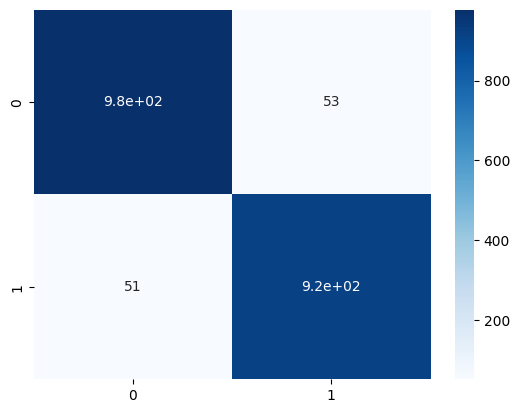

In [50]:
matrix1 = confusion_matrix(y_test, y_pred)
print(matrix1)
ax1 = sns.heatmap(matrix1, annot=True, cmap="Blues")
print(classification_report(y_test, y_pred))